# BAF EDA Gap Matrix

This notebook compares fraud detection approaches on the BAF (Bank Account Fraud) dataset.

- **Graph policy:** temporal kNN is only used to build similarity edges between applications.
- **Main metric:** PR-AUC on test month 7 (threshold tuned on validation month 6).
- **Ops metric:** a simple cost model for block vs alert cutoffs (HKD placeholders).


## 0. Setup

We use a fixed time split: **train months 0–5**, **validation month 6**, **test month 7**.
Graph edges only connect an account to neighbors from **earlier** months (no future leakage).
All BAF features are kept — nothing is dropped by hand.


In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.eda.feature_plots import draw_features_baf, list_baf_feature_columns
from src.graph.property_graph import (
    build_property_graph,
    property_graph_embeddings,
    property_graph_stats,
)
from src.graph.temporal_knn import (
    TemporalKNNConfig,
    build_temporal_knn_graph,
    mean_neighbor_features,
    temporal_knn_stats,
)
from src.modeling.cost_metrics import (
    CostConfig,
    build_cutoff_metrics_table,
    compute_revenue_tp_per_account,
    cost_check_fp_per_account,
    cost_unlock_fp_per_account,
    maximize_profit,
    plot_cutoff_economics,
)
from src.modeling.metrics import best_f1_threshold, calibrate_platt, evaluate_binary_classifier
from src.modeling.train_vanilla import train_vanilla
from src.modeling.xgb_runtime import resolve_xgb_compute
from src.preprocessing.baf_preprocessor import BAFPreprocessor, TimeSplit
from xgboost import XGBClassifier

COST_CONFIG = CostConfig(
    clerk_salary_hkd_annual=400_000,
    hours_per_month=160,
    hours_to_unlock_fp=32,
    hours_to_check_fp=8,
    fraud_volume_proxy_col="intended_balcon_amount",
)

CONFIG = {
    "seed": 42,
    "data_path": REPO_ROOT / "data" / "base.csv",
    "variant_paths": [REPO_ROOT / "data" / f"variant_{i}.csv" for i in range(1, 7)],
    "results_dir": REPO_ROOT / "results" / "eda_matrix",
    "stage1_variant": REPO_ROOT / "data" / "base.csv",
    "knn_k": 20,
    "knn_metric": "cosine",
    "knn_mutual": False,
    "use_smote_stage1": False,
    "use_yeo_johnson": True,
    "recall_at_precision": 0.8,
    "eda_plot_all_features": True,
    "eda_max_plots": None,
    "shap_sample_size": 500,
}

CONFIG["results_dir"].mkdir(parents=True, exist_ok=True)
np.random.seed(CONFIG["seed"])
print("Repo root:", REPO_ROOT)
print("Results:", CONFIG["results_dir"])


Repo root: /userhome/cs/khin/Fraud-Detection
Results: /userhome/cs/khin/Fraud-Detection/results/eda_matrix


## 1. Exploratory data analysis

Before building graphs or models, we look at the raw data: fraud rate by month, how each feature differs between fraud and non-fraud accounts, missing values, and numeric correlations.

Fraud exposure in the cost model later uses `intended_balcon_amount` as a **placeholder** — swap in real loss data when you have it.


Shape: (1000000, 32)
Features: 30 categorical: 11 numeric: 19

Fraud rate overall: 0.011029

Fraud rate by month:
        count  fraud_rate
month                    
0      132440    0.011326
1      127620    0.009387
2      136979    0.008746
3      150936    0.009222
4      127691    0.011371
5      119323    0.011825
6      108168    0.013405
7       96843    0.014746


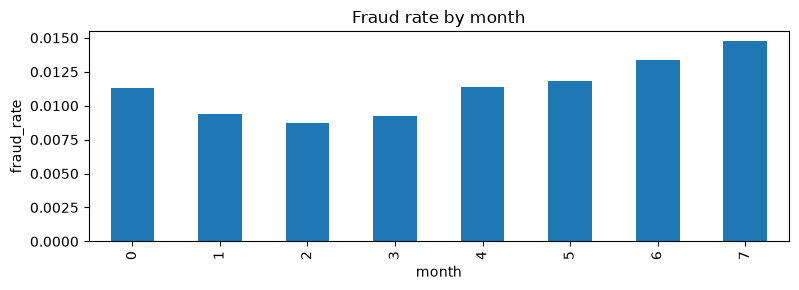

In [2]:
DATA_PATH = Path(CONFIG["stage1_variant"])
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"BAF CSV not found at {DATA_PATH}. Place base.csv under data/ or update CONFIG."
    )

df = pd.read_csv(DATA_PATH)
numeric_cols, categorical_cols = list_baf_feature_columns(df)
all_feature_cols = categorical_cols + numeric_cols
print("Shape:", df.shape)
print("Features:", len(all_feature_cols), "categorical:", len(categorical_cols), "numeric:", len(numeric_cols))
print("\nFraud rate overall:", df["fraud_bool"].mean())
print("\nFraud rate by month:")
print(df.groupby("month")["fraud_bool"].agg(["count", "mean"]).rename(columns={"mean": "fraud_rate"}))

fig, ax = plt.subplots(figsize=(8, 3))
df.groupby("month")["fraud_bool"].mean().plot(kind="bar", ax=ax, title="Fraud rate by month")
ax.set_ylabel("fraud_rate")
plt.tight_layout()
plt.show()


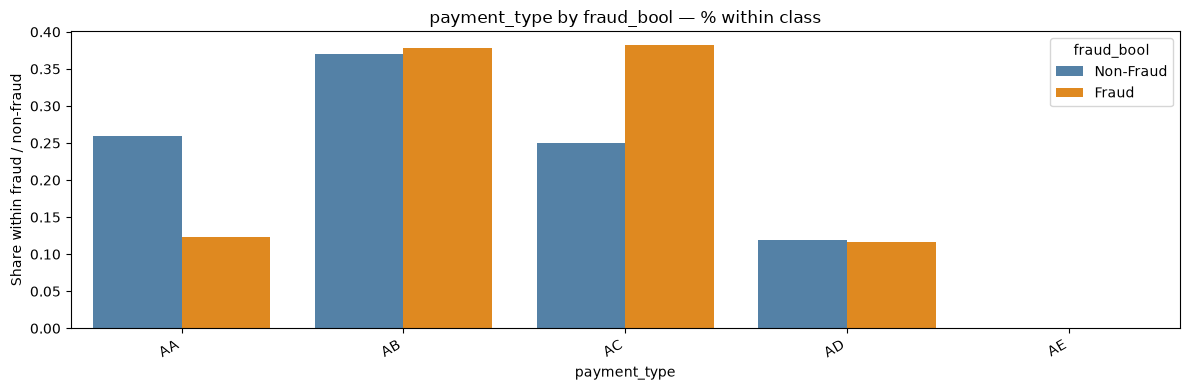

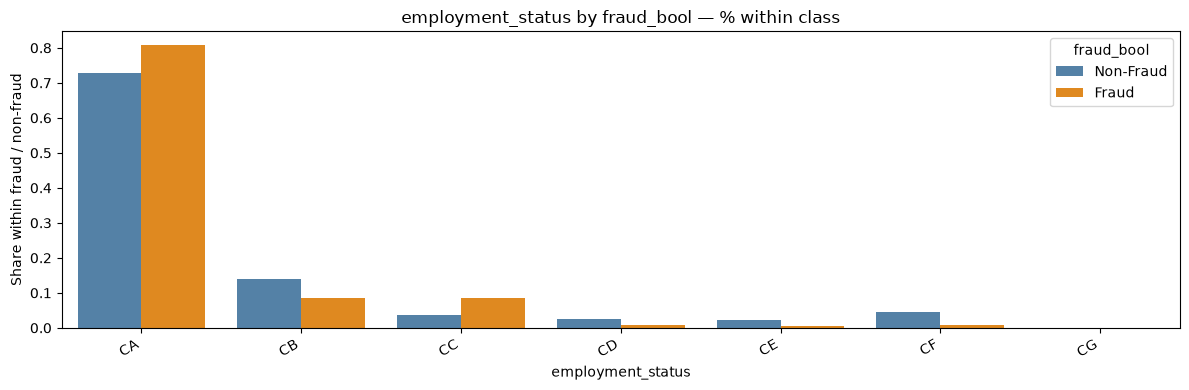

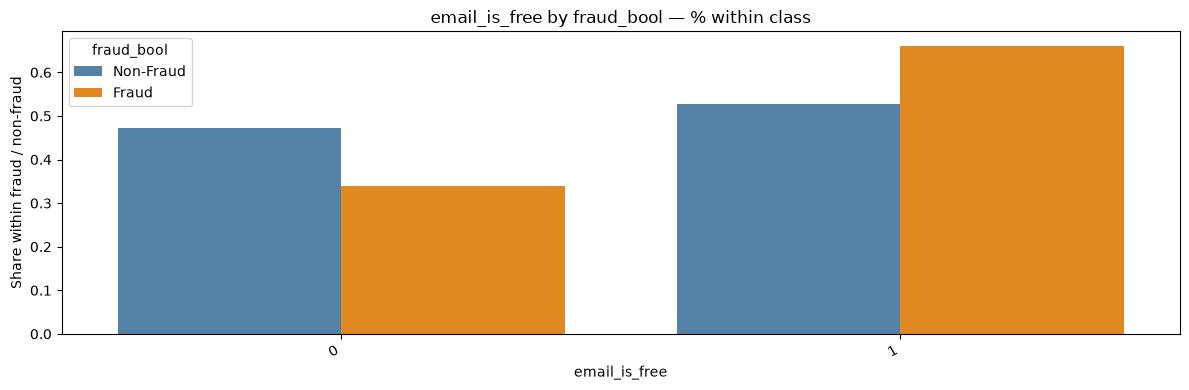

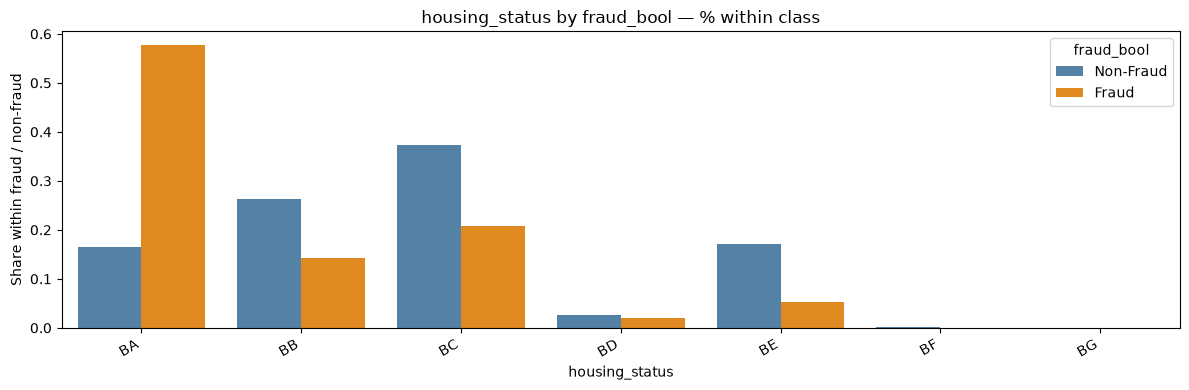

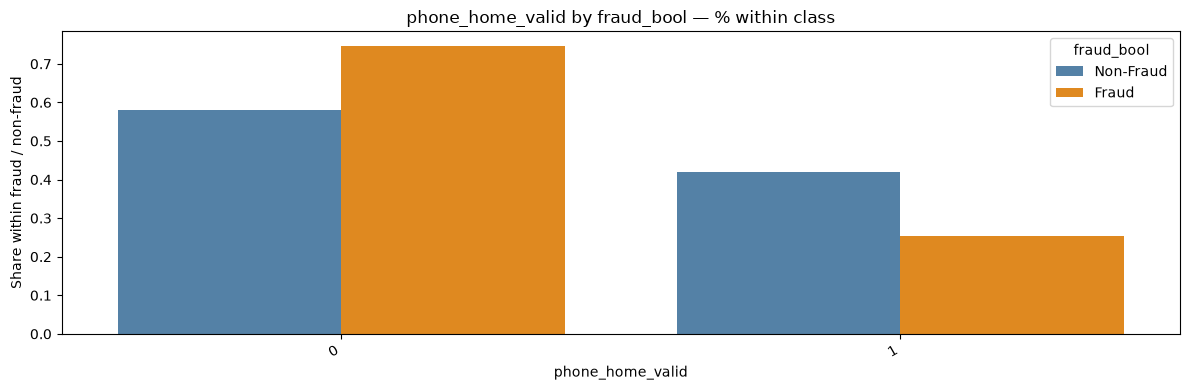

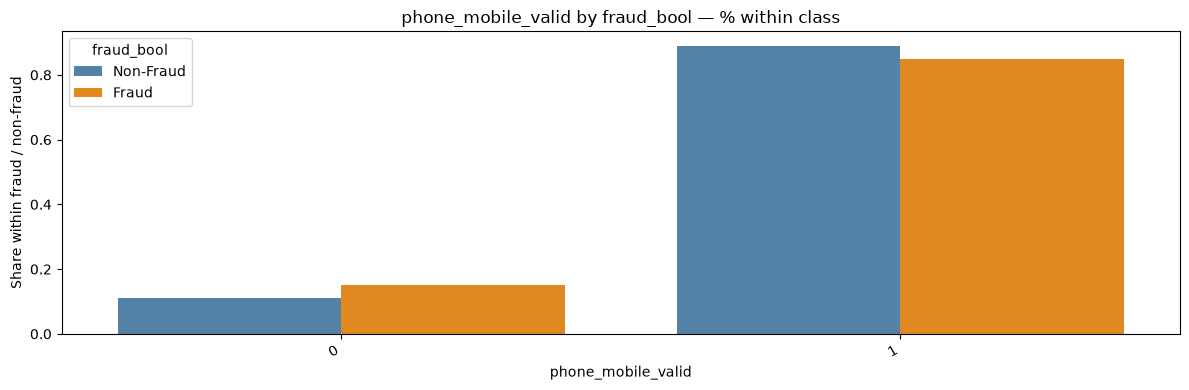

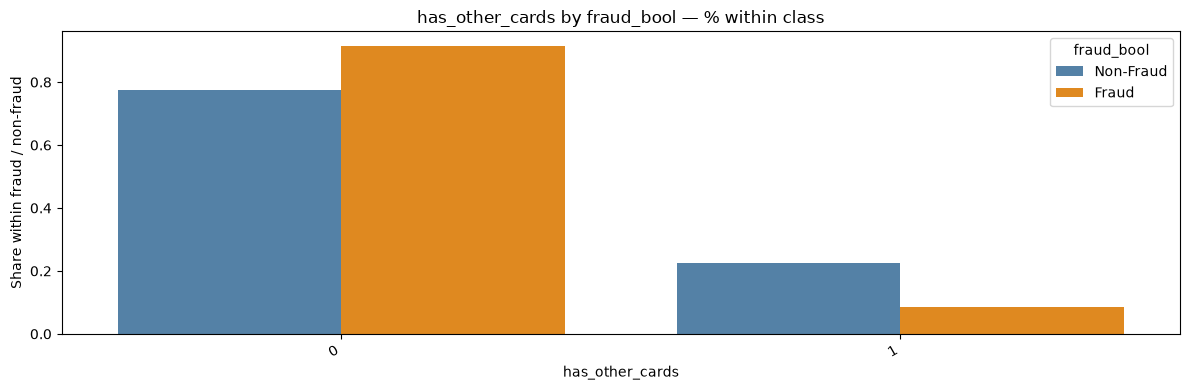

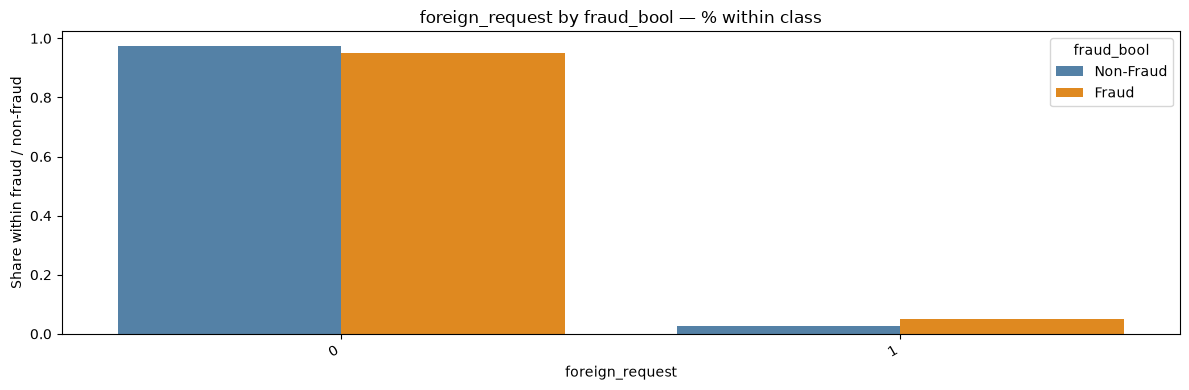

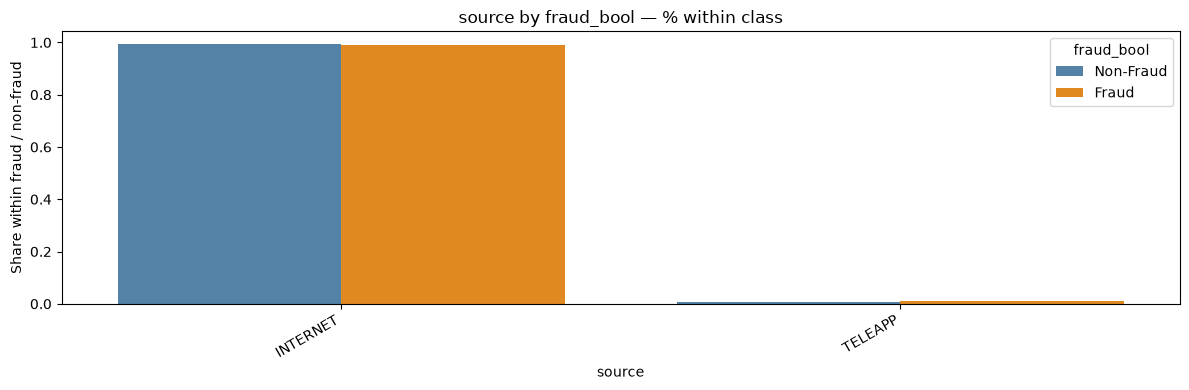

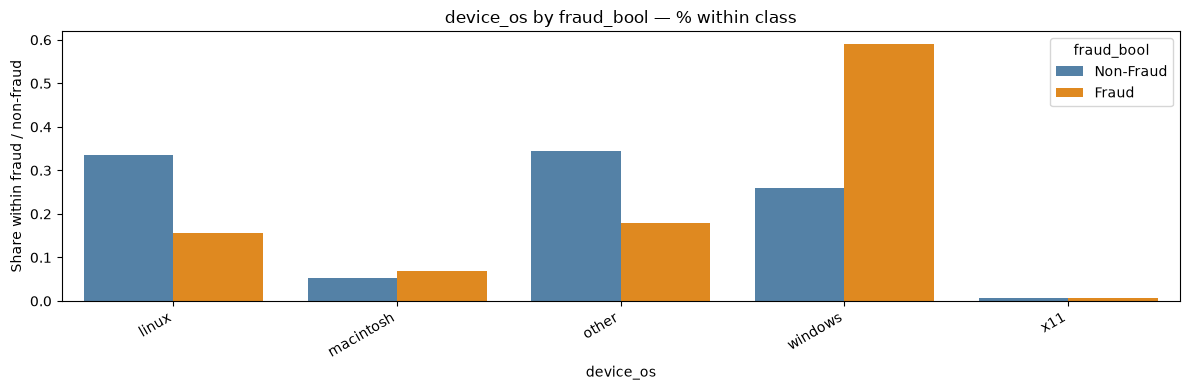

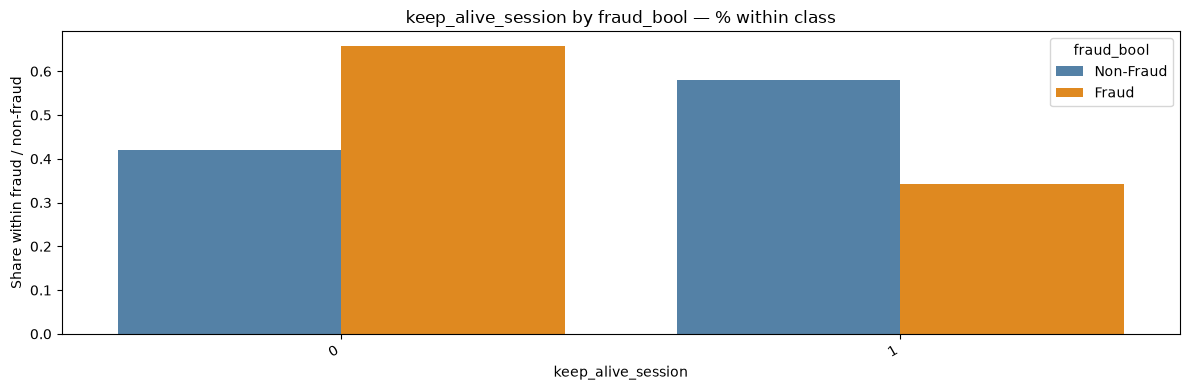

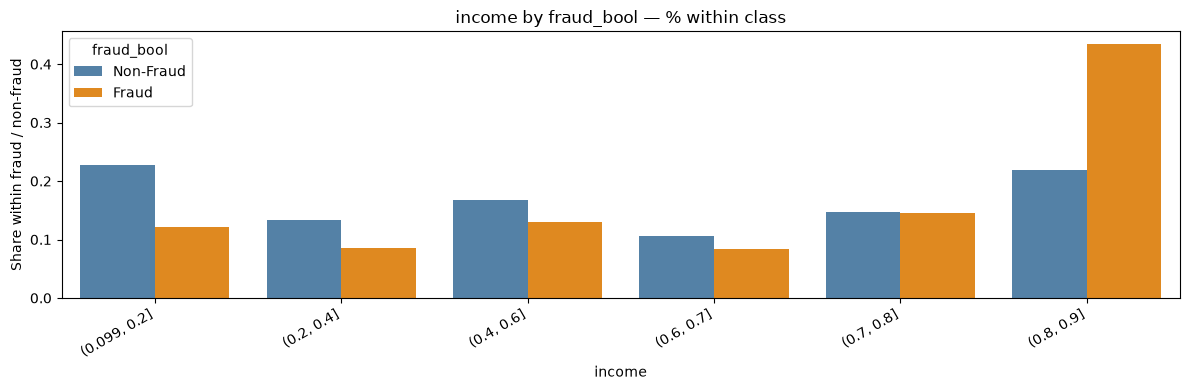

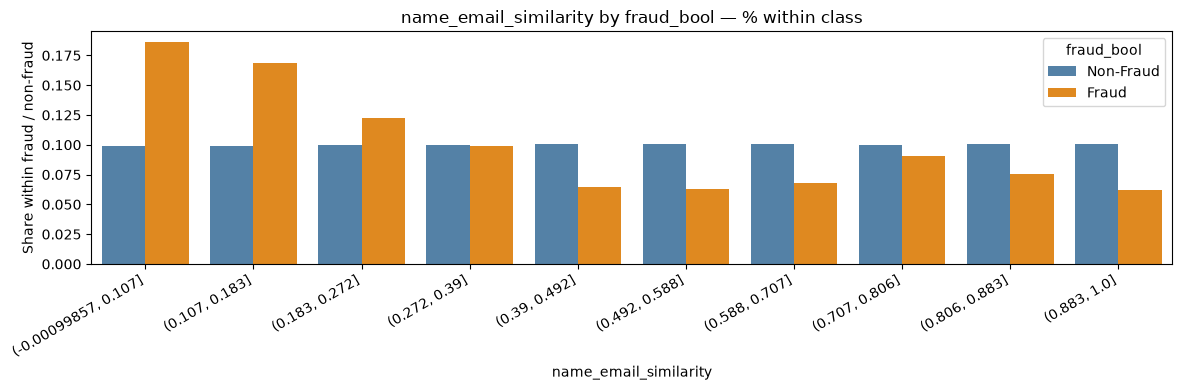

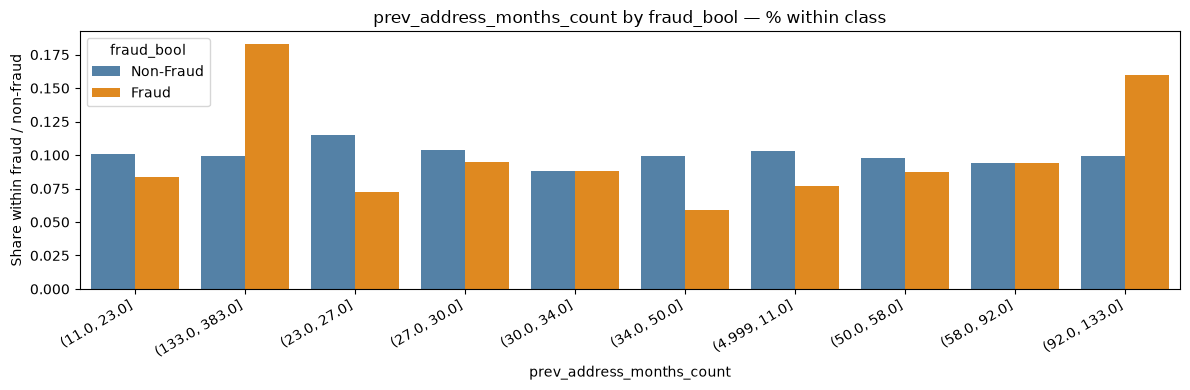

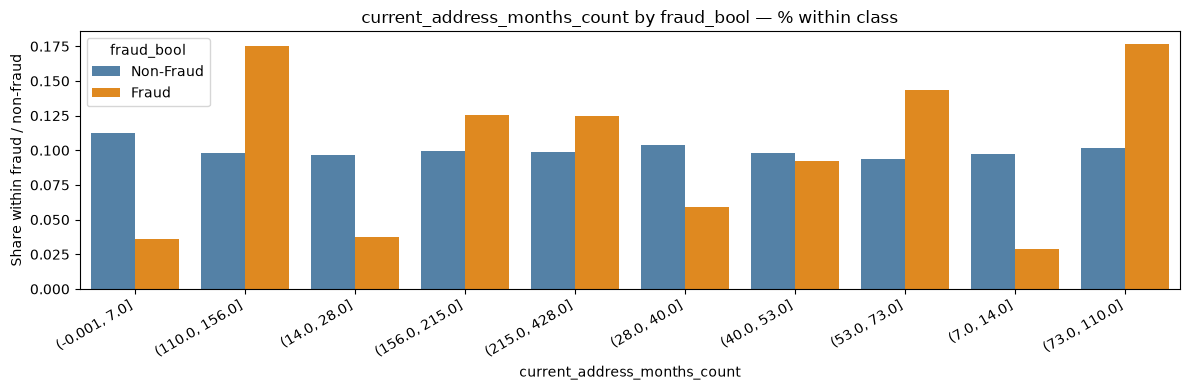

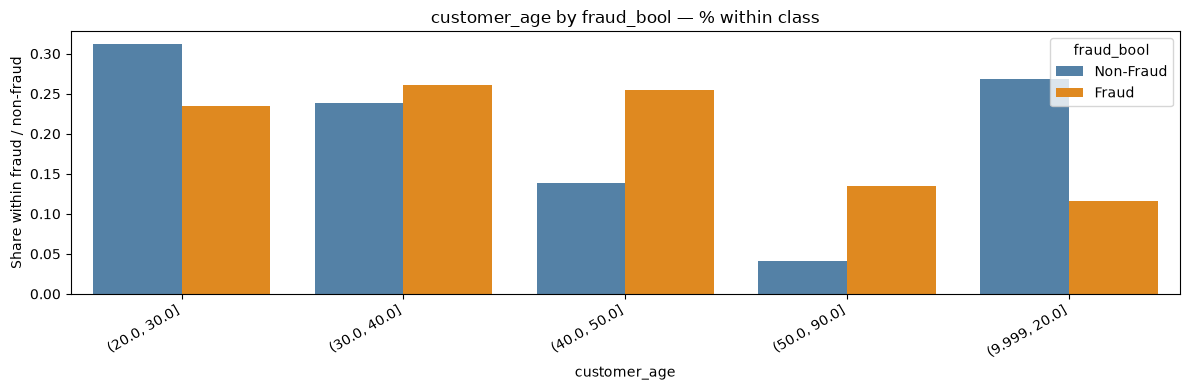

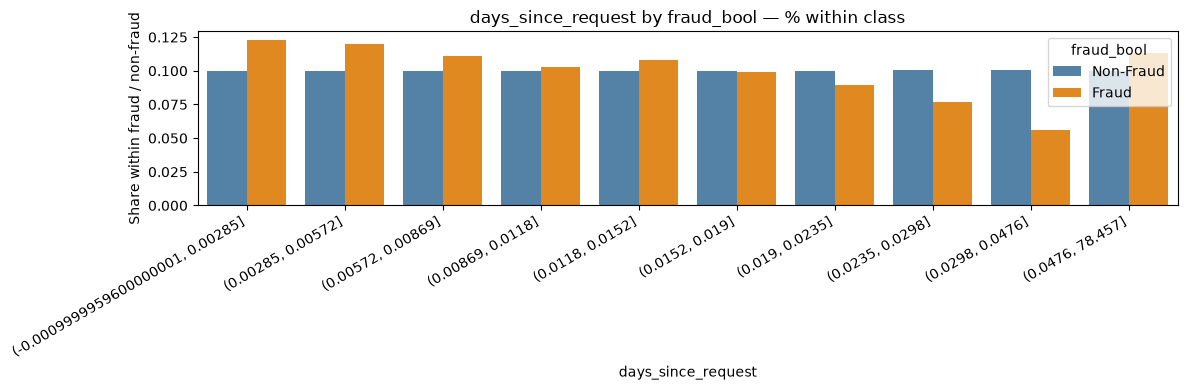

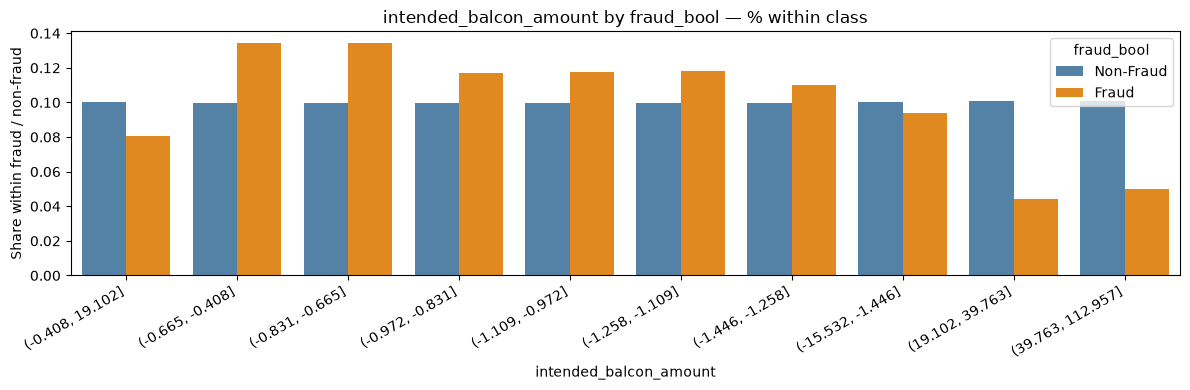

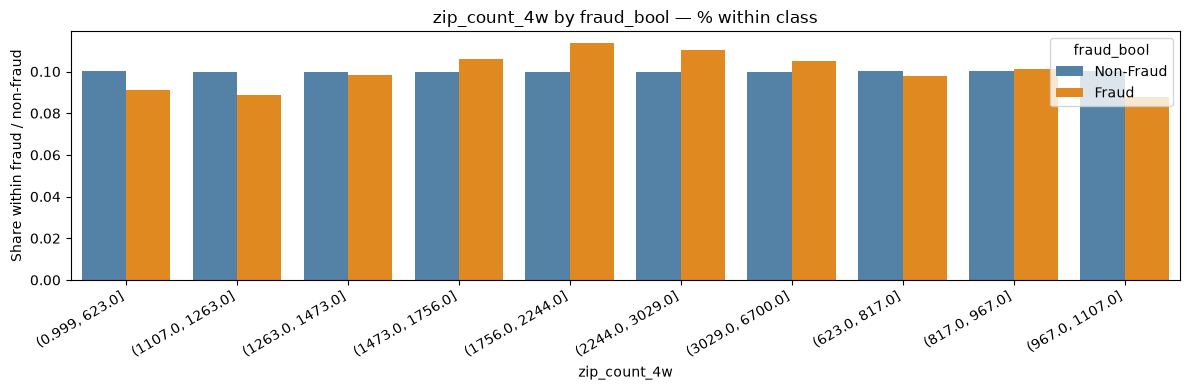

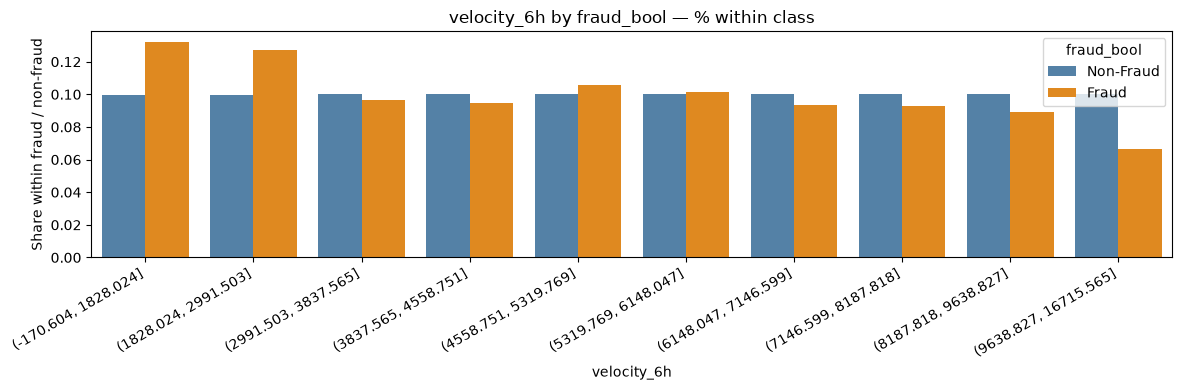

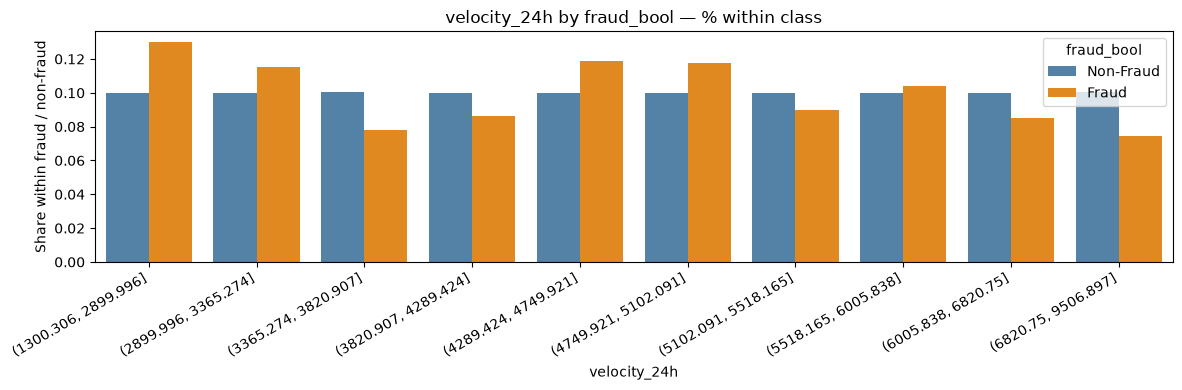

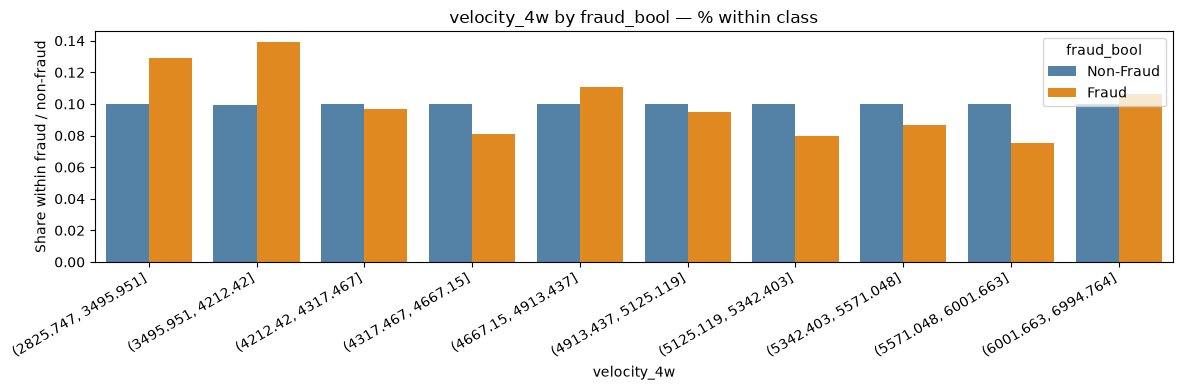

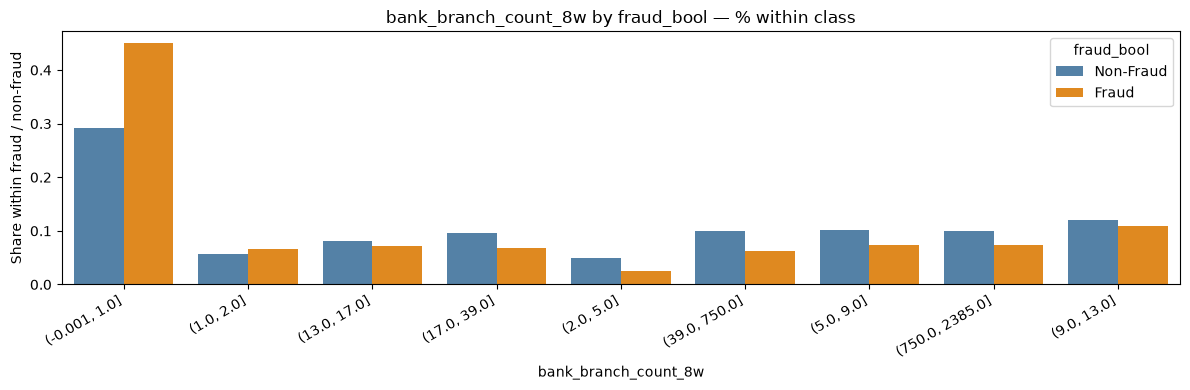

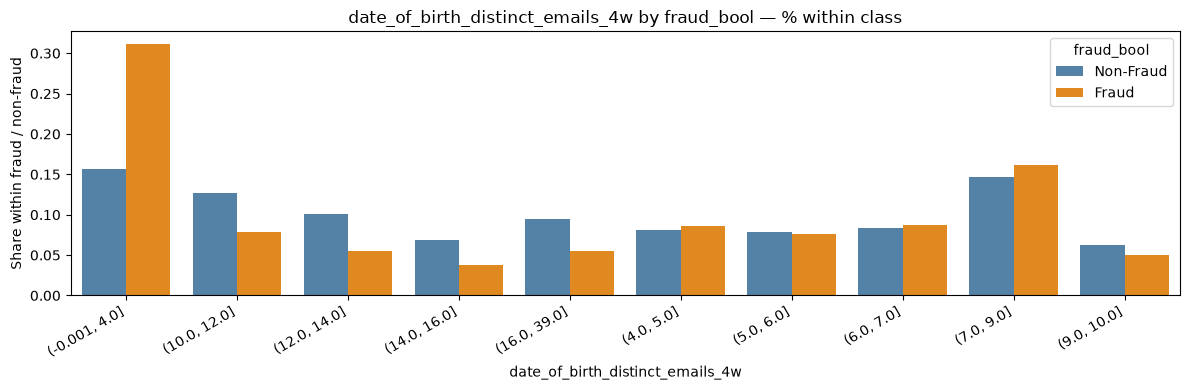

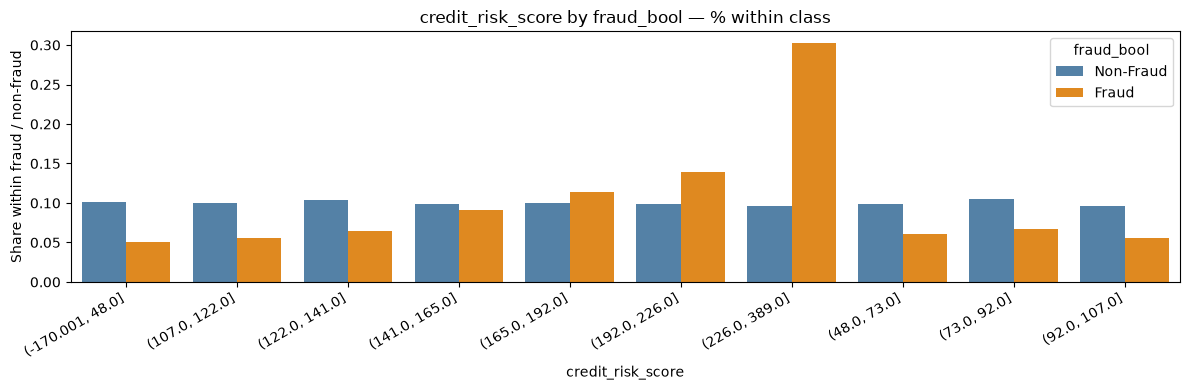

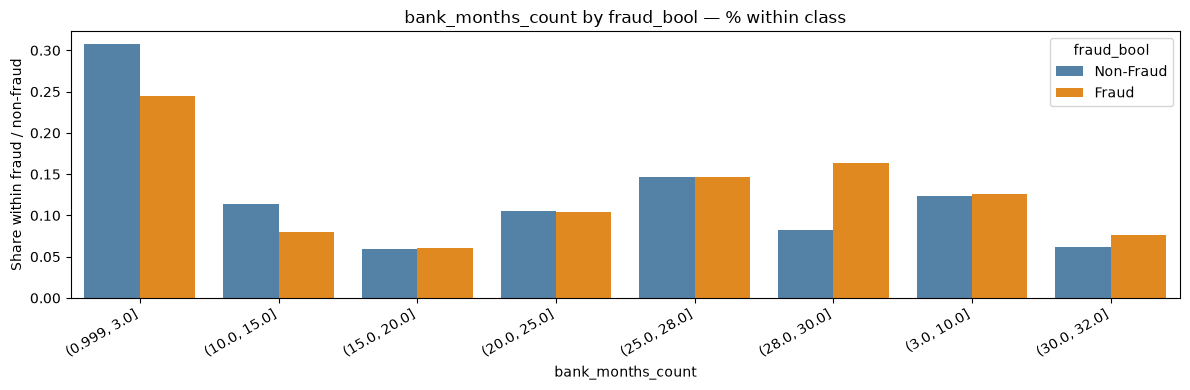

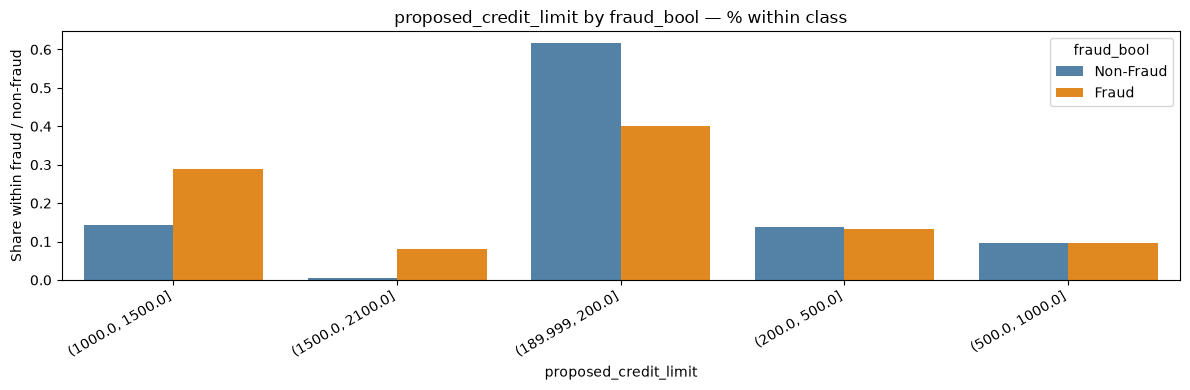

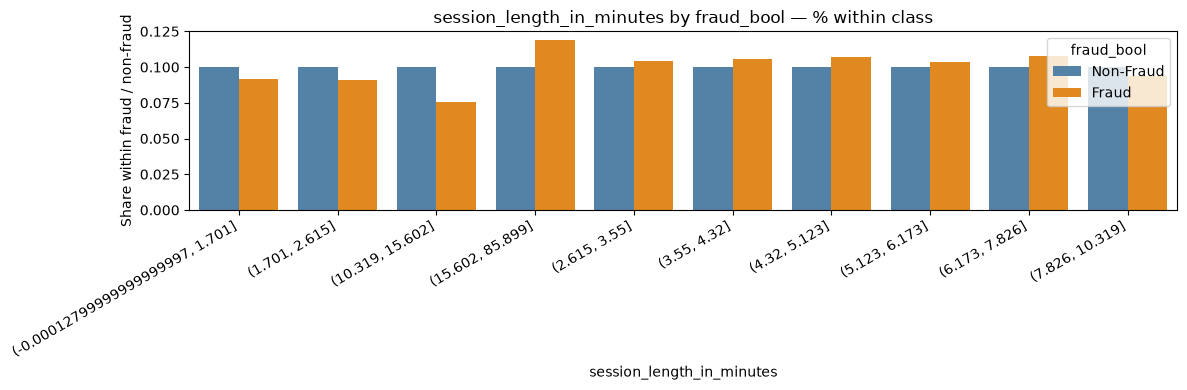

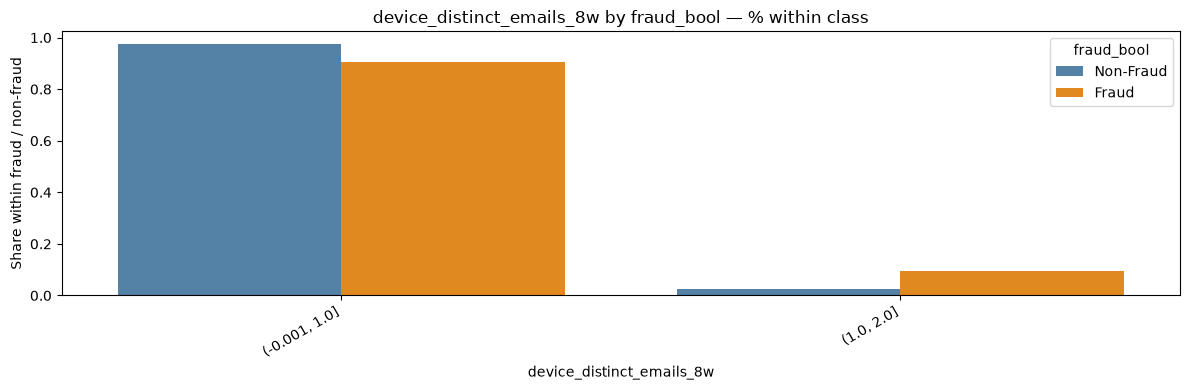

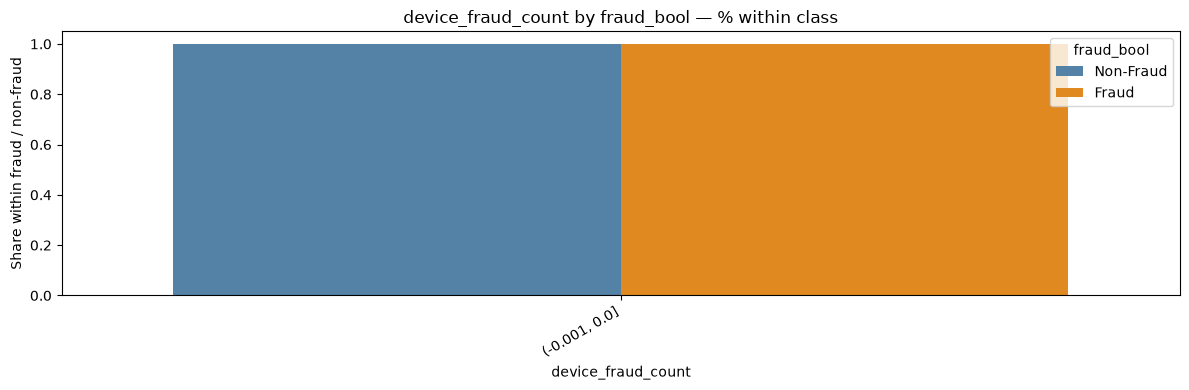

In [3]:
# Colab-style factor plots on all raw BAF columns
plot_cols = all_feature_cols
if CONFIG.get("eda_max_plots"):
    plot_cols = plot_cols[: CONFIG["eda_max_plots"]]
elif not CONFIG.get("eda_plot_all_features", True):
    plot_cols = plot_cols[:10]
draw_features_baf(df, feature_cols=plot_cols)


Top missing / -1 rates:
prev_address_months_count       0.712920
bank_months_count               0.253635
current_address_months_count    0.004254
session_length_in_minutes       0.002015
credit_risk_score               0.000488
device_distinct_emails_8w       0.000359
phone_mobile_valid              0.000000
has_other_cards                 0.000000
source                          0.000000
payment_type                    0.000000
email_is_free                   0.000000
housing_status                  0.000000
phone_home_valid                0.000000
employment_status               0.000000
name_email_similarity           0.000000
dtype: float64


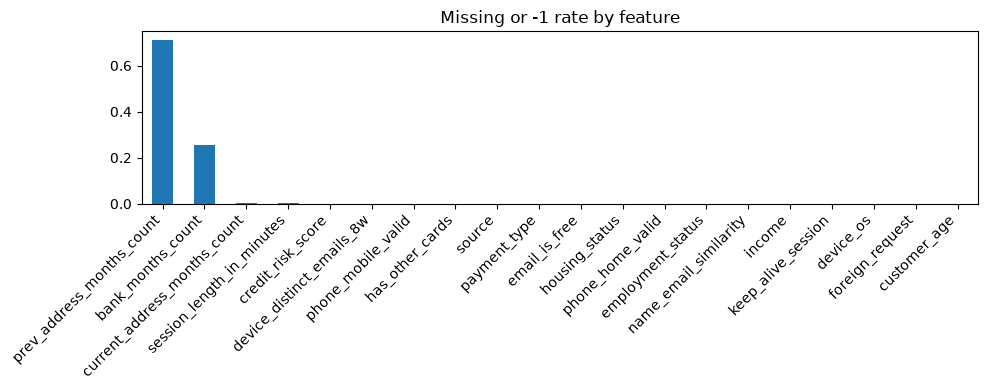

In [4]:
# Missingness and -1 markers
missing = df[all_feature_cols].replace(-1, np.nan).isna().mean().sort_values(ascending=False)
print("Top missing / -1 rates:")
print(missing.head(15))

fig, ax = plt.subplots(figsize=(10, 4))
missing.head(20).plot(kind="bar", ax=ax, title="Missing or -1 rate by feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


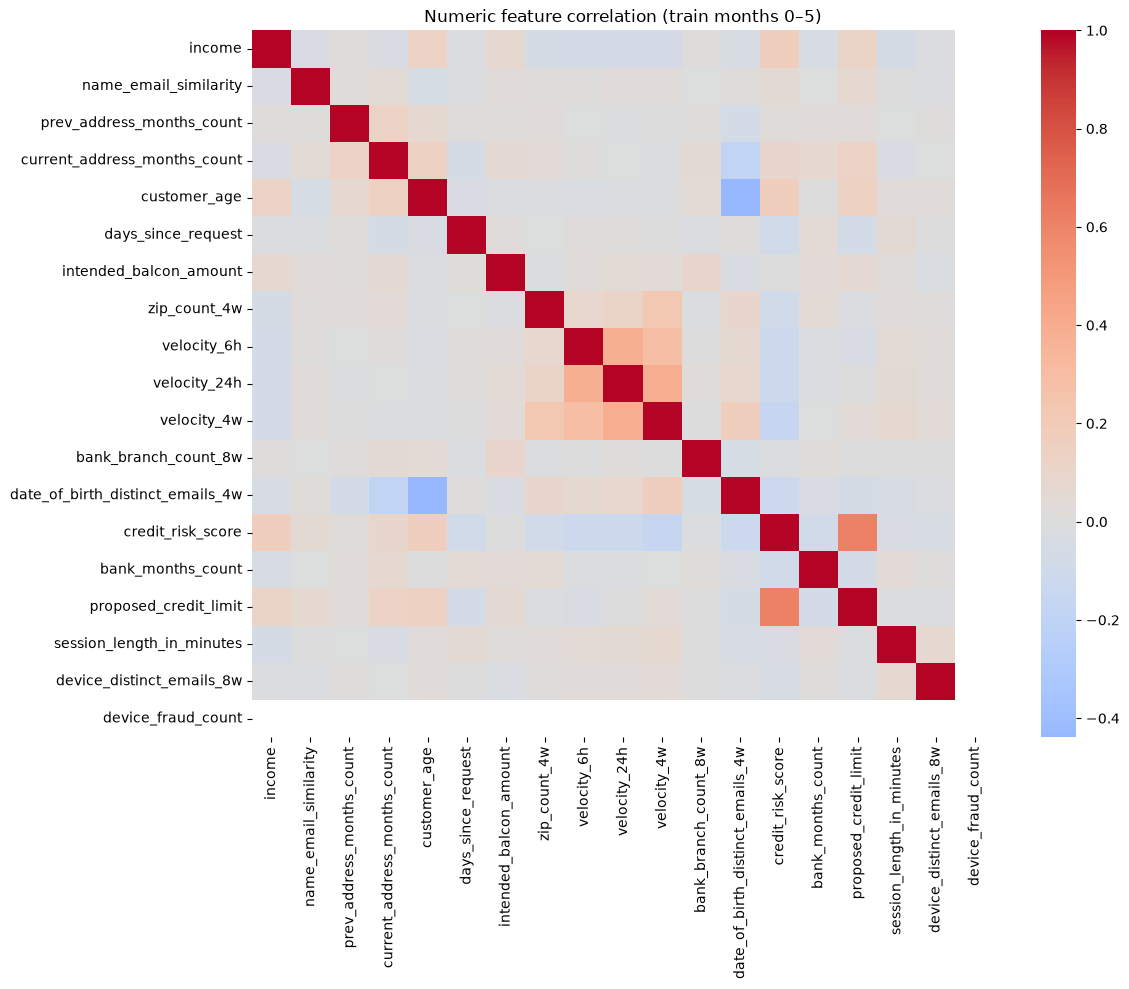

In [5]:
# Numeric correlation heatmap (train months only for leakage safety preview)
train_preview = df[df["month"].isin([0, 1, 2, 3, 4, 5])]
num_for_corr = [c for c in numeric_cols if train_preview[c].replace(-1, np.nan).notna().sum() > 0]
corr = train_preview[num_for_corr].replace(-1, np.nan).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=False)
plt.title("Numeric feature correlation (train months 0–5)")
plt.tight_layout()
plt.show()


## 2. Preprocessing

We fit the preprocessor on train months only (0–5). Validation and test months are transform-only, so the model never sees future data during fitting.


In [6]:
split = TimeSplit()
preprocessor = BAFPreprocessor(use_yeo_johnson=CONFIG["use_yeo_johnson"])
train_df, valid_df, test_df = preprocessor.split_by_month(df, split)
preprocessor.fit(train_df)

X_train, y_train = preprocessor.transform_with_target(train_df)
X_valid, y_valid = preprocessor.transform_with_target(valid_df)
X_test, y_test = preprocessor.transform_with_target(test_df)
feature_names = preprocessor.get_feature_names()

features_all = np.vstack([X_train.values, X_valid.values, X_test.values])
labels_all = np.concatenate([y_train.values, y_valid.values, y_test.values])
months_all = np.concatenate([
    train_df["month"].values,
    valid_df["month"].values,
    test_df["month"].values,
])
offsets = {
    "train": (0, len(train_df)),
    "valid": (len(train_df), len(train_df) + len(valid_df)),
    "test": (len(train_df) + len(valid_df), len(features_all)),
}
print("Train/valid/test:", X_train.shape, X_valid.shape, X_test.shape)
print("Preprocessed feature dim:", X_train.shape[1])
print("Sample feature names:", feature_names[:8], "...")


Train/valid/test: (794989, 52) (108168, 52) (96843, 52)
Preprocessed feature dim: 52
Sample feature names: ['income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'zip_count_4w'] ...


## 3. Anchor model (no graph)

Tabular XGBoost on all preprocessed features. This is the **baseline** every graph method is compared against.


In [7]:
anchor_out = CONFIG["results_dir"] / "anchor"
anchor_report = train_vanilla(
    DATA_PATH,
    output_dir=anchor_out,
    use_yeo_johnson=CONFIG["use_yeo_johnson"],
    use_smote=CONFIG["use_smote_stage1"],
    prefer_gpu=True,
)
anchor_model = joblib.load(anchor_out / "model.pkl")
test_pred_df = pd.read_csv(anchor_out / "test_predictions.csv")
anchor_test_scores = test_pred_df["score"].values
print("Anchor test PR-AUC:", anchor_report["metrics"]["pr_auc"])


/userhome/cs/khin/Fraud-Detection/.venv/lib/python3.12/site-packages/xgboost/core.py:553: UserWarning: [17:31:32] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Anchor test PR-AUC: 0.2114097419365134


## 4. Feature importances

Which features drive the anchor model? We plot XGBoost importances and optional SHAP values, then save the top features to CSV.


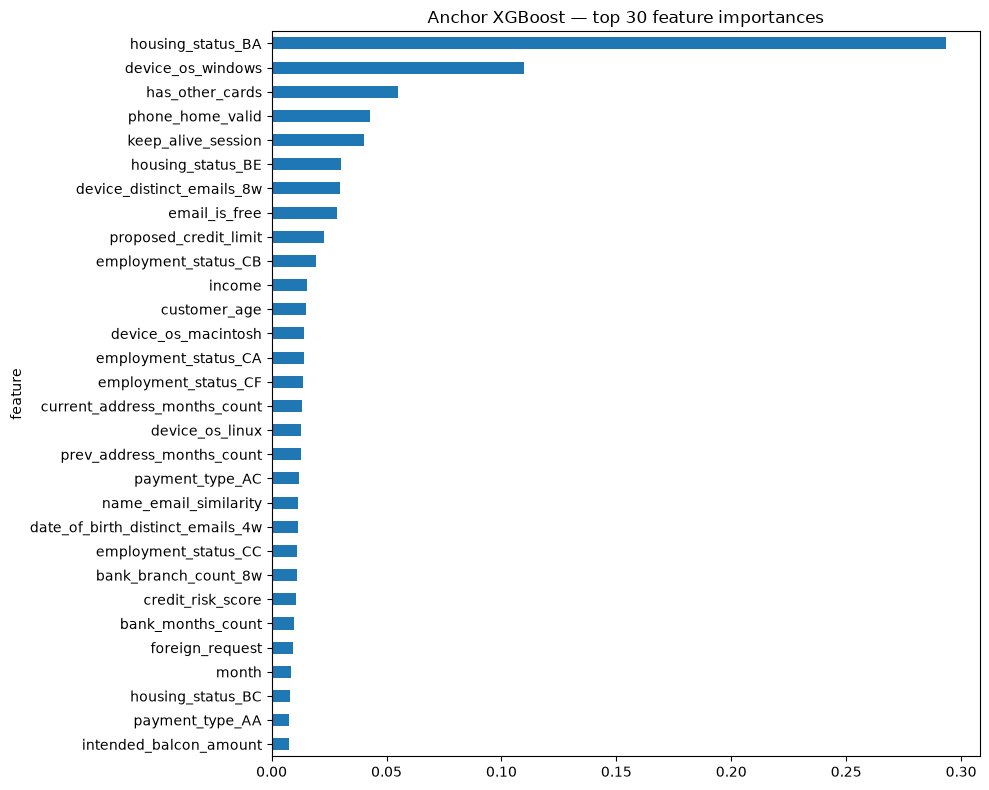

Exported: /userhome/cs/khin/Fraud-Detection/results/eda_matrix/feature_importance_anchor.csv
                      feature  importance  importance_pct
38          housing_status_BA    0.293537        0.293537
50          device_os_windows    0.109660        0.109660
18            has_other_cards    0.055069        0.055069
15           phone_home_valid    0.042894        0.042894
22         keep_alive_session    0.040018        0.040018
42          housing_status_BE    0.030195        0.030195
23  device_distinct_emails_8w    0.029590        0.029590
14              email_is_free    0.028587        0.028587
19      proposed_credit_limit    0.022642        0.022642
32       employment_status_CB    0.019325        0.019325


In [8]:
imp = pd.DataFrame({
    "feature": feature_names,
    "importance": anchor_model.feature_importances_,
}).sort_values("importance", ascending=False)
imp["importance_pct"] = imp["importance"] / imp["importance"].sum()

top_n = 30
fig, ax = plt.subplots(figsize=(10, 8))
imp.head(top_n).plot.barh(x="feature", y="importance", ax=ax, legend=False)
ax.invert_yaxis()
ax.set_title(f"Anchor XGBoost — top {top_n} feature importances")
plt.tight_layout()
plt.show()

imp_path = CONFIG["results_dir"] / "feature_importance_anchor.csv"
imp.to_csv(imp_path, index=False)
print("Exported:", imp_path)
print(imp.head(10))


/userhome/cs/khin/Fraud-Detection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_1282577/3862966750.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, feature_names=feature_names, max_display=20, show=False)


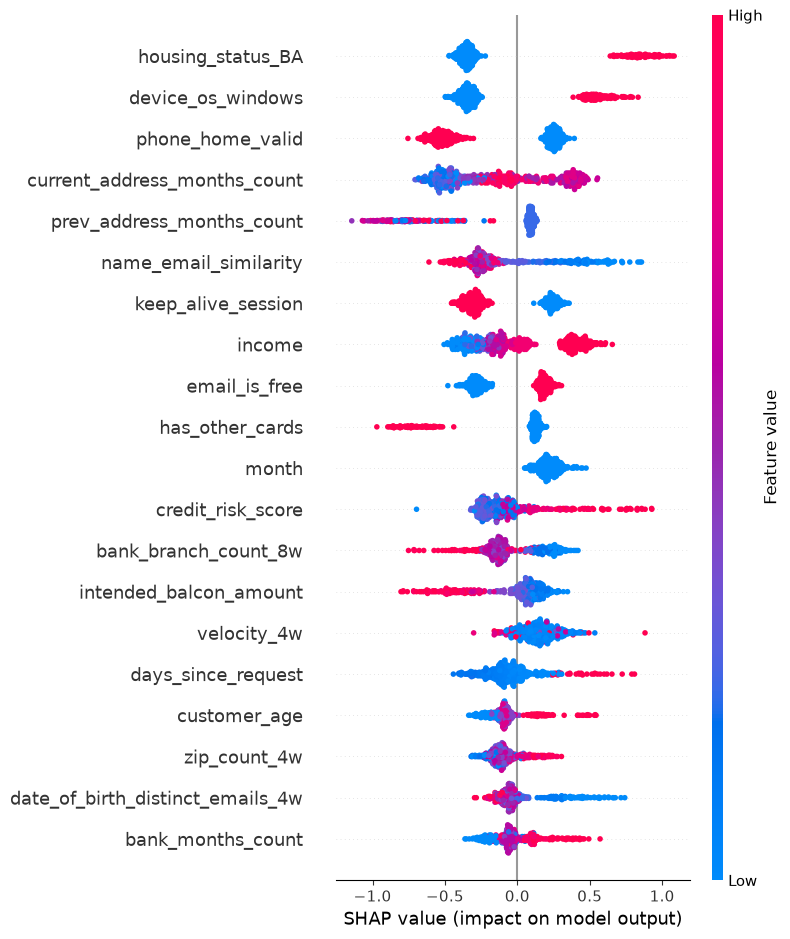

In [9]:
try:
    import shap

    shap_n = min(CONFIG["shap_sample_size"], len(X_test))
    shap_idx = np.random.choice(len(X_test), shap_n, replace=False)
    X_shap = X_test.iloc[shap_idx]
    explainer = shap.TreeExplainer(anchor_model)
    shap_values = explainer.shap_values(X_shap)
    shap.summary_plot(shap_values, X_shap, feature_names=feature_names, max_display=20, show=False)
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print("SHAP skipped:", exc)


## 5. Temporal kNN graph

Connect each application to similar past applications (cosine kNN, k=20). Edges must satisfy `neighbor_month < query_month`.

Cosine similarity compares **patterns** (angles); it works well with mixed numeric and one-hot features.


In [10]:
knn_cfg = TemporalKNNConfig(
    k=CONFIG["knn_k"],
    metric=CONFIG["knn_metric"],
    mutual=CONFIG["knn_mutual"],
)
knn_edges = build_temporal_knn_graph(features_all, months_all, labels_all, knn_cfg)
knn_stats = temporal_knn_stats(knn_edges, labels_all, months_all)
print("Temporal kNN stats:", json.dumps(knn_stats, indent=2))
assert knn_stats["temporal_violations"] == 0, "Temporal leakage in kNN graph!"

knn_embeddings = mean_neighbor_features(features_all, knn_edges, len(features_all))
print("kNN embedding shape:", knn_embeddings.shape)


Temporal kNN stats: {
  "n_nodes": 1000000,
  "n_edges": 4817411,
  "density": 4.817415817415818e-06,
  "avg_degree": 5.883408055319102,
  "homophily": 0.9785413783461697,
  "temporal_violations": 0
}


kNN embedding shape: (1000000, 52)


## 6. Property graph

A second graph links applications to shared entities (device, source, etc.). Neither graph replaces tabular features — they add embeddings for a GNN→XGBoost stack.


Property graph stats: {
  "n_application_nodes": 1000000,
  "n_entity_nodes": 23,
  "n_edges": 6000000,
  "avg_app_degree": 6.0,
  "n_edge_types": 6
}
Entity node sample:
   node_id  node_type     value
0       -1     source  INTERNET
1       -2     source   TELEAPP
2       -3  device_os     linux
3       -4  device_os     other
4       -5  device_os   windows


Property embedding shape: (1000000, 52)


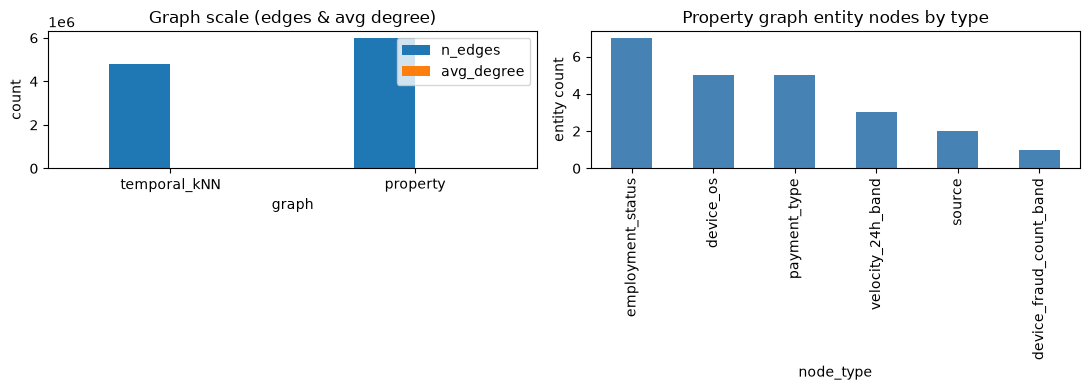

In [2]:
app_nodes, prop_edges, entity_nodes = build_property_graph(df)
prop_stats = property_graph_stats(app_nodes, prop_edges, labels_all)
print("Property graph stats:", json.dumps(prop_stats, indent=2))
print("Entity node sample:")
print(entity_nodes.head())

prop_embeddings = property_graph_embeddings(features_all, prop_edges, len(features_all))
print("Property embedding shape:", prop_embeddings.shape)

# Graph topology comparison (kNN vs property)
graph_compare = pd.DataFrame([
    {"graph": "temporal_kNN", "n_edges": knn_stats["n_edges"], "avg_degree": knn_stats["avg_degree"], "n_nodes": knn_stats["n_nodes"]},
    {"graph": "property", "n_edges": prop_stats["n_edges"], "avg_degree": prop_stats["avg_app_degree"], "n_nodes": prop_stats["n_application_nodes"]},
])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
graph_compare.set_index("graph")[["n_edges", "avg_degree"]].plot.bar(ax=axes[0], rot=0)
axes[0].set_title("Graph scale (edges & avg degree)")
axes[0].set_ylabel("count")
entity_counts = entity_nodes.groupby("node_type").size().sort_values(ascending=False)
entity_counts.plot.bar(ax=axes[1], color="steelblue")
axes[1].set_title("Property graph entity nodes by type")
axes[1].set_ylabel("entity count")
plt.tight_layout()
plt.show()


## 7. Stage 1 — graph comparison

Compare three setups on test PR-AUC:
1. Tabular anchor (no graph)
2. Tabular + temporal kNN embeddings
3. Tabular + property graph embeddings


/userhome/cs/khin/Fraud-Detection/.venv/lib/python3.12/site-packages/xgboost/core.py:553: UserWarning: [10:23:25] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


          graph            model    pr_auc    recall  brier_calibrated  \
0          none  XGBoost_tabular  0.211410  0.290616          0.013564   
1  temporal_kNN   GNN_to_XGBoost  0.209937  0.253501          0.013586   
2      property   GNN_to_XGBoost  0.211588  0.364146          0.013551   

   alert_yield_pct  
0         1.535475  
1         1.341346  
2         2.307859  


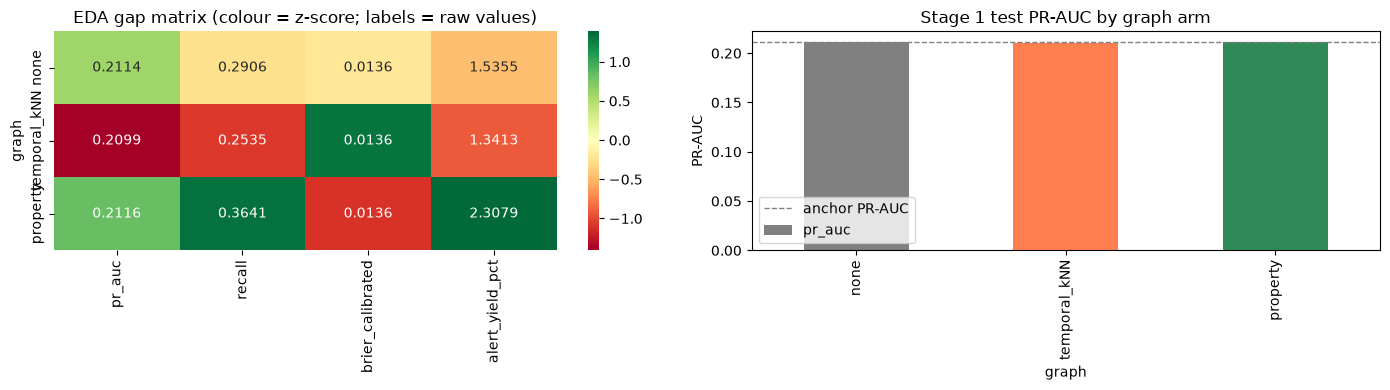

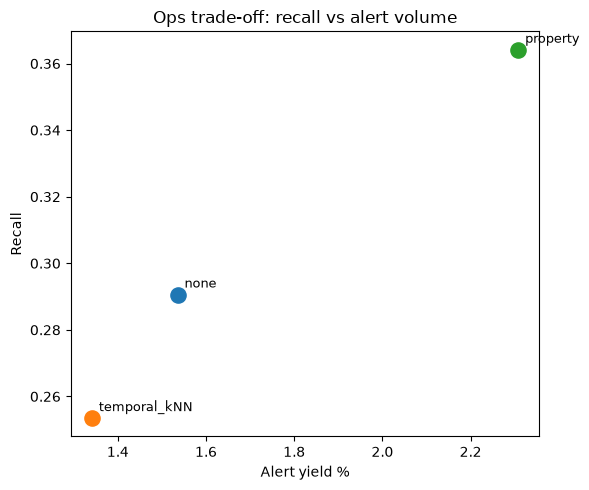

In [3]:
def train_graph_xgb(name, graph_features, use_smote=False):
    X_tr = np.hstack([X_train.values, graph_features[offsets["train"][0]:offsets["train"][1]]])
    X_va = np.hstack([X_valid.values, graph_features[offsets["valid"][0]:offsets["valid"][1]]])
    X_te = np.hstack([X_test.values, graph_features[offsets["test"][0]:offsets["test"][1]]])
    y_tr, y_va, y_te = y_train.values, y_valid.values, y_test.values

    if use_smote:
        from imblearn.over_sampling import SMOTE
        smote = SMOTE(sampling_strategy=0.5, random_state=CONFIG["seed"])
        X_tr, y_tr = smote.fit_resample(X_tr, y_tr)

    compute = resolve_xgb_compute(prefer_gpu=True)
    model = XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        objective="binary:logistic",
        eval_metric="aucpr",
        random_state=CONFIG["seed"],
        tree_method=compute["tree_method"],
        device=compute["device"],
    )
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    valid_scores = model.predict_proba(X_va)[:, 1]
    test_scores = model.predict_proba(X_te)[:, 1]
    calibrator = calibrate_platt(y_va, valid_scores)
    test_cal = calibrator.model.predict_proba(test_scores.reshape(-1, 1))[:, 1]
    threshold = best_f1_threshold(y_va, valid_scores)
    metrics = evaluate_binary_classifier(y_te, test_scores, test_cal, threshold)
    return {"name": name, "metrics": metrics, "test_scores": test_scores}


def _stage1_graph_label(row: dict) -> str:
    if "graph" in row:
        return str(row["graph"])
    return str(row["name"]).replace("_GNN_to_XGBoost", "")


def _stage1_model_label(row: dict) -> str:
    model = row.get("model", "GNN_to_XGBoost")
    return model if isinstance(model, str) else "GNN_to_XGBoost"


stage1_rows = [
    {"graph": "none", "model": "XGBoost_tabular", "metrics": anchor_report["metrics"], "test_scores": anchor_test_scores},
]
for label, emb in [("temporal_kNN", knn_embeddings), ("property", prop_embeddings)]:
    stage1_rows.append(train_graph_xgb(f"{label}_GNN_to_XGBoost", emb))

stage1_df = pd.DataFrame([
    {
        "graph": _stage1_graph_label(r),
        "model": _stage1_model_label(r),
        "pr_auc": r["metrics"]["pr_auc"],
        "recall": r["metrics"]["recall"],
        "brier_calibrated": r["metrics"]["brier_calibrated"],
        "alert_yield_pct": r["metrics"]["alert_yield_pct"],
    }
    for r in stage1_rows
])
print(stage1_df)
stage1_df.to_csv(CONFIG["results_dir"] / "stage1_results.csv", index=False)

# Stage 1 EDA gap matrix visualizations
metric_cols = ["pr_auc", "recall", "brier_calibrated", "alert_yield_pct"]
gap_matrix = stage1_df.set_index("graph")[metric_cols]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
gap_z = gap_matrix.apply(lambda col: (col - col.mean()) / (col.std(ddof=0) or 1), axis=0)
sns.heatmap(gap_z, annot=gap_matrix.round(4), fmt="", cmap="RdYlGn", center=0, ax=axes[0])
axes[0].set_title("EDA gap matrix (colour = z-score; labels = raw values)")
colors = {"none": "gray", "temporal_kNN": "coral", "property": "seagreen"}
stage1_df.plot.bar(x="graph", y="pr_auc", ax=axes[1], legend=False, color=[colors.get(g, "steelblue") for g in stage1_df["graph"]])
axes[1].axhline(anchor_report["metrics"]["pr_auc"], color="gray", ls="--", lw=1, label="anchor PR-AUC")
axes[1].set_title("Stage 1 test PR-AUC by graph arm")
axes[1].set_ylabel("PR-AUC")
axes[1].legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
for _, row in stage1_df.iterrows():
    ax.scatter(row["alert_yield_pct"], row["recall"], s=120)
    ax.annotate(row["graph"], (row["alert_yield_pct"], row["recall"]), xytext=(5, 5), textcoords="offset points", fontsize=9)
ax.set_xlabel("Alert yield %")
ax.set_ylabel("Recall")
ax.set_title("Ops trade-off: recall vs alert volume")
plt.tight_layout()
plt.show()


## 8. Business cost model

Turn model scores into a rough dollars story:
- **Revenue** when we correctly catch fraud (proxy per account)
- **Unlock cost** when we wrongly block a good customer
- **Check cost** when an analyst reviews an alert

We search for the best pair of BLOCK (high cutoff) and ALERT (lower cutoff) thresholds. Salary and hour assumptions are placeholders — replace with real ops data.


In [4]:
revenue_tp = compute_revenue_tp_per_account(
    train_df,
    volume_col=COST_CONFIG.fraud_volume_proxy_col,
)
cost_unlock = cost_unlock_fp_per_account(COST_CONFIG)
cost_check = cost_check_fp_per_account(COST_CONFIG)

cost_assumptions = {
    "clerk_salary_hkd_annual": COST_CONFIG.clerk_salary_hkd_annual,
    "hours_per_month": COST_CONFIG.hours_per_month,
    "hours_to_unlock_fp": COST_CONFIG.hours_to_unlock_fp,
    "hours_to_check_fp": COST_CONFIG.hours_to_check_fp,
    "fraud_volume_proxy_col": COST_CONFIG.fraud_volume_proxy_col,
    "revenue_tp_per_account_hkd": revenue_tp,
    "cost_unlock_fp_hkd": cost_unlock,
    "cost_check_fp_hkd": cost_check,
    "note": "Proxy for blocked fraudulent exposure; replace with real fraud volume when available.",
}
assumptions_path = CONFIG["results_dir"] / "cost_assumptions.json"
assumptions_path.write_text(json.dumps(cost_assumptions, indent=2))
print(json.dumps(cost_assumptions, indent=2))


{
  "clerk_salary_hkd_annual": 400000,
  "hours_per_month": 160,
  "hours_to_unlock_fp": 32,
  "hours_to_check_fp": 8,
  "fraud_volume_proxy_col": "intended_balcon_amount",
  "revenue_tp_per_account_hkd": 4.275304112391783,
  "cost_unlock_fp_hkd": 6666.666666666667,
  "cost_check_fp_hkd": 1666.6666666666667,
  "note": "Proxy for blocked fraudulent exposure; replace with real fraud volume when available."
}


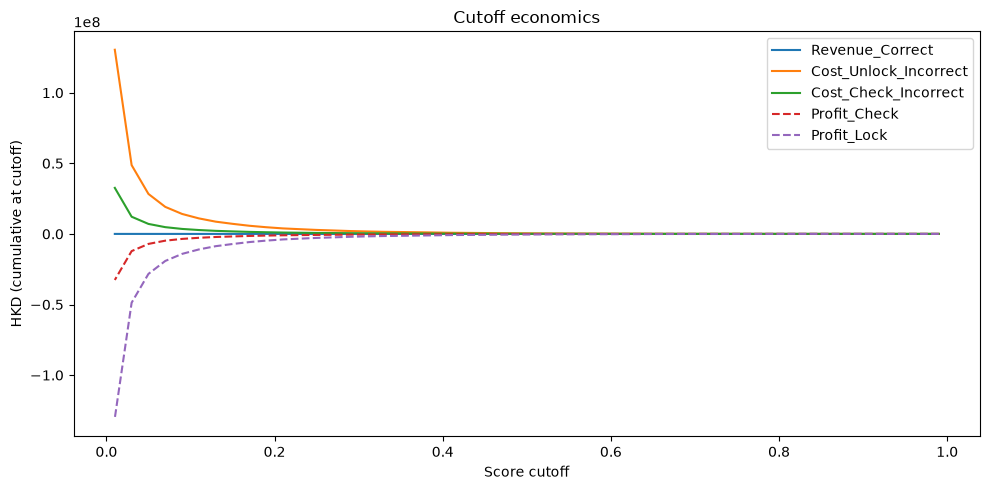

Optimal cutoffs: {
  "block_idx": 7,
  "alert_idx": 8,
  "block_cutoff": 0.85,
  "alert_cutoff": 0.8300000000000001,
  "block_predicted": 9,
  "alert_predicted": 9,
  "clerks_per_month_estimate": 0.0,
  "expected_profit_hkd": 38.477737011526045
}
Exported: /userhome/cs/khin/Fraud-Detection/results/eda_matrix/cutoff_economics.csv /userhome/cs/khin/Fraud-Detection/results/eda_matrix/optimal_cutoffs.json


In [5]:
cutoff_metrics = build_cutoff_metrics_table(
    y_test.values,
    anchor_test_scores,
    revenue_tp=revenue_tp,
    cost_unlock_fp=cost_unlock,
    cost_check_fp=cost_check,
)
cutoff_path = CONFIG["results_dir"] / "cutoff_economics.csv"
cutoff_metrics.to_csv(cutoff_path, index=False)

optimal = maximize_profit(cutoff_metrics, cost_check_fp=cost_check, config=COST_CONFIG)
alert_band = max(optimal["alert_predicted"] - optimal["block_predicted"], 0)
optimal["expected_profit_hkd"] = optimal.pop("max_profit")
optimal_path = CONFIG["results_dir"] / "optimal_cutoffs.json"
optimal_path.write_text(json.dumps(optimal, indent=2))

fig, ax = plt.subplots(figsize=(10, 5))
plot_cutoff_economics(cutoff_metrics, ax=ax)
plt.tight_layout()
plt.show()

print("Optimal cutoffs:", json.dumps(optimal, indent=2))
print("Exported:", cutoff_path, optimal_path)


## 9. Ablation experiments

Optional extra runs after Stage 1:
- **Stage 2:** does Yeo-Johnson scaling or SMOTE change anchor PR-AUC? (4 configs)
- **Stage 4:** how stable is the model across six BAF data variants?

Set `RUN_STAGE2` / `RUN_STAGE4` to `True`, or use `bash scripts/hku/run_ablation_experiments.sh` to run them without redoing EDA or kNN.


In [2]:
RUN_STAGE2 = True
stage2_results = []
stage2_df = None

if RUN_STAGE2:
    for use_yj in [True, False]:
        for use_smote in [False, True]:
            report = train_vanilla(
                DATA_PATH,
                output_dir=CONFIG["results_dir"] / f"anchor_yj{use_yj}_smote{use_smote}",
                use_yeo_johnson=use_yj,
                use_smote=use_smote,
                prefer_gpu=True,
            )
            stage2_results.append({
                "arm": "anchor",
                "use_yeo_johnson": use_yj,
                "use_smote": use_smote,
                "pr_auc": report["metrics"]["pr_auc"],
                "recall": report["metrics"]["recall"],
            })
    stage2_df = pd.DataFrame(stage2_results)
    stage2_df.to_csv(CONFIG["results_dir"] / "stage2_ablations.csv", index=False)
    print(stage2_df)
else:
    print("Stage 2 skipped — set RUN_STAGE2=True or run scripts/hku/run_ablation_experiments.sh")


/userhome/cs/khin/Fraud-Detection/.venv/lib/python3.12/site-packages/xgboost/core.py:553: UserWarning: [17:48:37] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


      arm  use_yeo_johnson  use_smote    pr_auc    recall
0  anchor             True      False  0.211410  0.290616
1  anchor             True       True  0.193671  0.345238
2  anchor            False      False  0.212652  0.271709
3  anchor            False       True  0.189346  0.287115


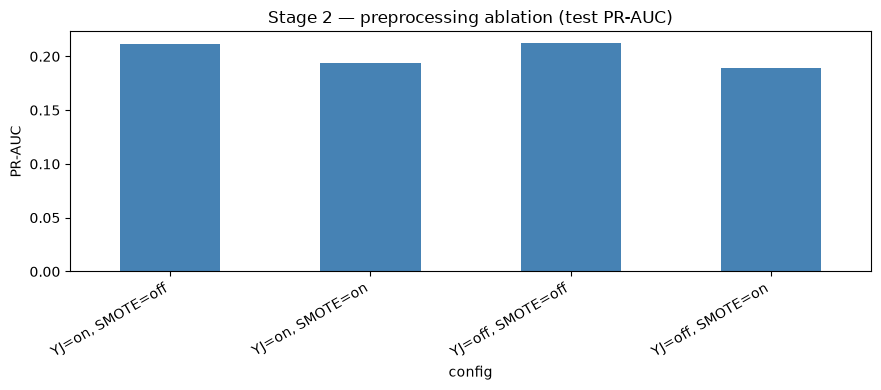

Best: Yeo-Johnson=off, SMOTE=off → PR-AUC 0.2127


In [3]:
if RUN_STAGE2 and stage2_results:
    stage2_df = pd.DataFrame(stage2_results)
    stage2_df["label"] = stage2_df.apply(
        lambda r: f"YJ={'on' if r['use_yeo_johnson'] else 'off'}, SMOTE={'on' if r['use_smote'] else 'off'}",
        axis=1,
    )
    best2 = stage2_df.sort_values('pr_auc', ascending=False).iloc[0]
    fig, ax = plt.subplots(figsize=(9, 4))
    stage2_df.plot.bar(x='label', y='pr_auc', ax=ax, legend=False, color='steelblue')
    ax.set_title('Stage 2 — preprocessing ablation (test PR-AUC)')
    ax.set_ylabel('PR-AUC')
    ax.set_xlabel('config')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
    print(
        f"Best: Yeo-Johnson={'on' if best2['use_yeo_johnson'] else 'off'}, "
        f"SMOTE={'on' if best2['use_smote'] else 'off'} → PR-AUC {best2['pr_auc']:.4f}"
    )


In [4]:
RUN_STAGE4 = True
variant_rows = []
variant_df = None

if RUN_STAGE4:
    for vpath in CONFIG["variant_paths"]:
        if not vpath.exists():
            print("Skip missing:", vpath)
            continue
        report = train_vanilla(
            vpath,
            output_dir=CONFIG["results_dir"] / vpath.stem,
            use_yeo_johnson=CONFIG["use_yeo_johnson"],
            use_smote=CONFIG["use_smote_stage1"],
            prefer_gpu=True,
        )
        variant_rows.append({"variant": vpath.stem, "pr_auc": report["metrics"]["pr_auc"]})
    variant_df = pd.DataFrame(variant_rows)
    variant_df.to_csv(CONFIG["results_dir"] / "stage4_variants.csv", index=False)
    print(variant_df)
    print(variant_df["pr_auc"].describe())
else:
    print("Stage 4 skipped — set RUN_STAGE4=True or run scripts/hku/run_ablation_experiments.sh")


     variant    pr_auc
0  variant_1  0.210899
1  variant_2  0.217311
2  variant_3  0.513981
3  variant_4  0.097353
4  variant_5  0.058949
5  variant_6  0.211410
count    6.000000
mean     0.218317
std      0.159719
min      0.058949
25%      0.125740
50%      0.211155
75%      0.215835
max      0.513981
Name: pr_auc, dtype: float64


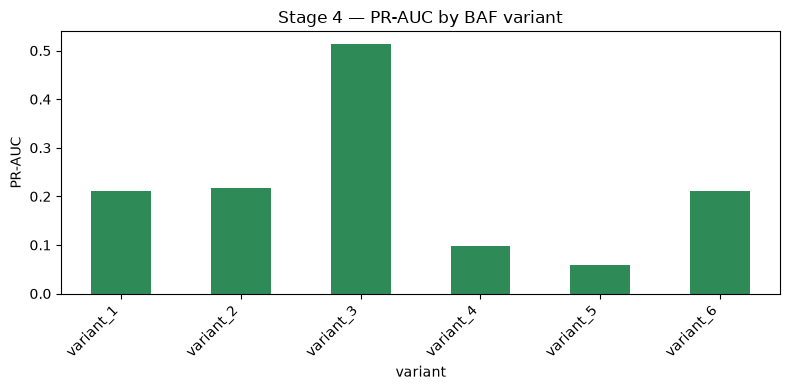

PR-AUC range: 0.0589 – 0.5140 (std 0.1597)


In [5]:
if RUN_STAGE4 and variant_rows:
    variant_df = pd.DataFrame(variant_rows)
    fig, ax = plt.subplots(figsize=(8, 4))
    variant_df.plot.bar(x='variant', y='pr_auc', ax=ax, legend=False, color='seagreen')
    ax.set_title('Stage 4 — PR-AUC by BAF variant')
    ax.set_ylabel('PR-AUC')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    pr = variant_df['pr_auc']
    print(f"PR-AUC range: {pr.min():.4f} – {pr.max():.4f} (std {pr.std():.4f})")


## 10. Conclusions and exports

Save graph stats, champion config, and CSVs for downstream work. The next cell prints a plain-language summary of what we found.


In [6]:
from src.modeling.ablation_summary import format_conclusion_markdown, load_ablation_artifacts

artifacts = load_ablation_artifacts(CONFIG["results_dir"])
if 'stage1_df' not in artifacts:
    artifacts['stage1_df'] = stage1_df
if RUN_STAGE2 and stage2_results:
    artifacts['stage2_df'] = pd.DataFrame(stage2_results)
if RUN_STAGE4 and variant_rows:
    artifacts['stage4_df'] = pd.DataFrame(variant_rows)
if 'optimal' not in artifacts:
    artifacts['optimal'] = optimal

conclusion_text = format_conclusion_markdown(artifacts)
print(conclusion_text)
(CONFIG["results_dir"] / "conclusion.md").write_text(conclusion_text)
print("\nSaved:", CONFIG["results_dir"] / "conclusion.md")


## What we found

- **Best graph setup:** property (PR-AUC 0.212 on test month 7), compared with tabular anchor PR-AUC 0.211.
- **Property graph** caught more fraud (recall 36.4%) than the anchor (29.1%), with a small rise in alerts flagged.
- **Temporal kNN** did not beat the tabular baseline on PR-AUC in this run.
- **Preprocessing ablation:** best combo was Yeo-Johnson off, SMOTE off (PR-AUC 0.213).
- **Variant benchmark:** PR-AUC ranged from 0.059 to 0.514 across 6 BAF variants (std 0.160).
- **Cost model (anchor scores):** optimal cutoffs block at 0.85 and alert at 0.83. Expected profit is about HKD 38.48 on test month 7 — a rough proxy, not real bank savings.

## What to do next

- Use **property** graph features as the default for the next modeling stage.
- Replace the fraud revenue proxy with real loss data before trusting the cost model.
- Re-run ablations if you change preprocessing or download new BAF variants.

Saved: /userhome/cs/khin/Fraud-Detection/results/eda_matrix/con

Exported: /userhome/cs/khin/Fraud-Detection/results/eda_matrix
Champion: {
  "graph": "property",
  "model": "GNN_to_XGBoost",
  "pr_auc_test": 0.2115879846245739,
  "stage1_complete": true,
  "stage2_complete": true,
  "stage4_complete": true,
  "optimal_block_cutoff": 0.85,
  "optimal_alert_cutoff": 0.8300000000000001,
  "expected_profit_hkd": 38.477737011526045,
  "best_preprocess": {
    "use_yeo_johnson": false,
    "use_smote": false,
    "pr_auc": 0.21265161893544227
  },
  "variant_pr_auc_min": 0.058949172692379,
  "variant_pr_auc_max": 0.5139808399768006
}


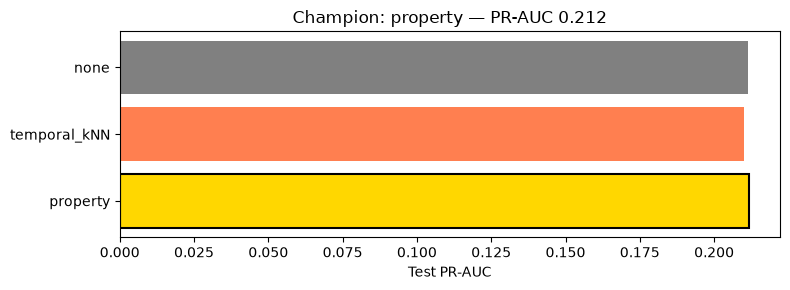

In [7]:
from src.modeling.ablation_summary import best_preprocess_config

graph_stats = {
    "temporal_knn": knn_stats,
    "property_graph": prop_stats,
    "knn_policy": "graph_edges_only_no_tabular_enrichment",
    "n_raw_features": len(all_feature_cols),
    "n_preprocessed_features": len(feature_names),
    "config": {k: str(v) for k, v in CONFIG.items()},
    "cost_assumptions": cost_assumptions,
}
(CONFIG["results_dir"] / "graph_stats.json").write_text(json.dumps(graph_stats, indent=2))

best_row = stage1_df.sort_values("pr_auc", ascending=False).iloc[0]
champion = {
    "graph": best_row["graph"],
    "model": best_row["model"],
    "pr_auc_test": float(best_row["pr_auc"]),
    "stage1_complete": True,
    "stage2_complete": bool(RUN_STAGE2 and stage2_results),
    "stage4_complete": bool(RUN_STAGE4 and variant_rows),
    "optimal_block_cutoff": optimal["block_cutoff"],
    "optimal_alert_cutoff": optimal["alert_cutoff"],
    "expected_profit_hkd": optimal["expected_profit_hkd"],
}
if RUN_STAGE2 and stage2_results:
    champion["best_preprocess"] = best_preprocess_config(pd.DataFrame(stage2_results))
if RUN_STAGE4 and variant_rows:
    vdf = pd.DataFrame(variant_rows)
    champion["variant_pr_auc_min"] = float(vdf["pr_auc"].min())
    champion["variant_pr_auc_max"] = float(vdf["pr_auc"].max())

(CONFIG["results_dir"] / "champion_config.json").write_text(json.dumps(champion, indent=2))

print("Exported:", CONFIG["results_dir"])
print("Champion:", json.dumps(champion, indent=2))

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(stage1_df["graph"], stage1_df["pr_auc"], color=[colors.get(g, "steelblue") for g in stage1_df["graph"]])
ax.barh(champion["graph"], champion["pr_auc_test"], color="gold", edgecolor="black", linewidth=1.5)
ax.set_xlabel("Test PR-AUC")
ax.set_title(f"Champion: {champion['graph']} — PR-AUC {champion['pr_auc_test']:.3f}")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
